## Download dataset


In [1]:
import pandas as pd
import os 
from pathlib import Path

BASE_DIR = os.path.dirname(os.path.abspath("__file__"))
RAWDATA_PATH = os.path.join(BASE_DIR, "..", "data", "LD2011_2014.txt")

df = pd.read_csv(RAWDATA_PATH, 
                 sep=";", 
                 decimal=",", 
                 parse_dates=[0],
                 index_col=0)

In [2]:
df.info()

print('min value = ', df.min().min())
print('max value = ', df.max().max())

print('shape = ', df.shape)
print('count of na = ', df.isna().sum().sum())


<class 'pandas.DataFrame'>
DatetimeIndex: 140256 entries, 2011-01-01 00:15:00 to 2015-01-01 00:00:00
Columns: 370 entries, MT_001 to MT_370
dtypes: float64(370)
memory usage: 397.0 MB
min value =  0.0
max value =  192800.0
shape =  (140256, 370)
count of na =  0


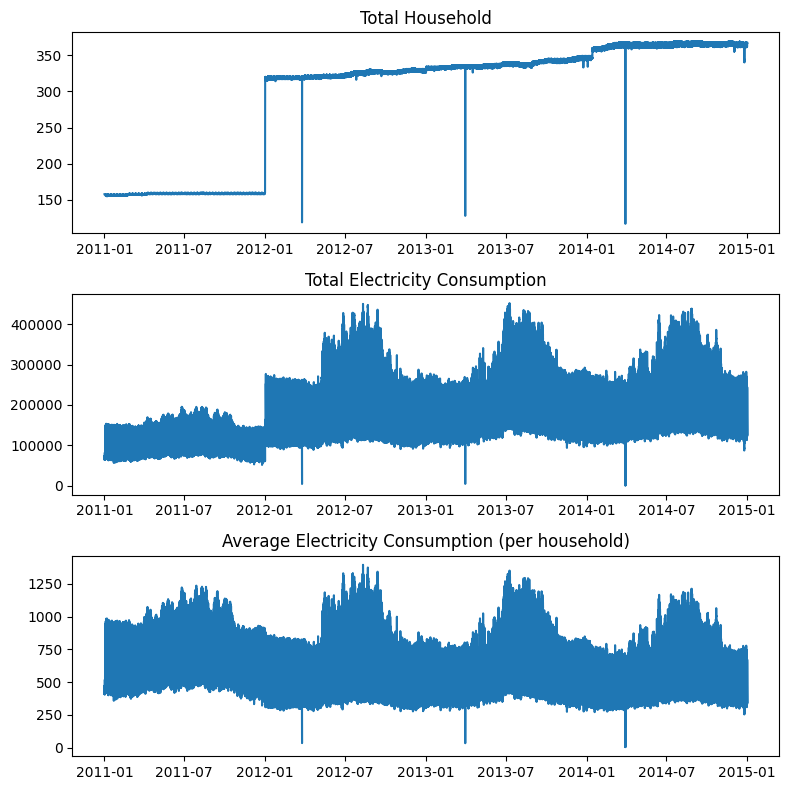

In [3]:
import matplotlib.pyplot as plt

total_count = (df != 0).sum(axis=1)

total_load = df.sum(axis=1) 

plt.figure(figsize = (8,8))

plt.subplot(3,1,1)
plt.plot(total_count)
plt.title('Total Household')

plt.subplot(3,1,2)
plt.plot(total_load)
plt.title('Total Electricity Consumption')

plt.subplot(3,1,3)
plt.plot(total_load/total_count)
plt.title('Average Electricity Consumption (per household)')

plt.tight_layout()
plt.show()

In [6]:

# Check dataset shape (rows, columns)
n_rows, n_cols = df.shape
print(f"Data shape: {n_rows} rows × {n_cols} columns")

# Find device_id that doesn't start with zeros
print("Columns with non-zero first value:")
print(df.columns[df.iloc[0] != 0])

Data shape: 140256 rows × 370 columns
Columns with non-zero first value:
Index(['MT_124', 'MT_131', 'MT_132', 'MT_156', 'MT_158', 'MT_159', 'MT_161',
       'MT_162', 'MT_163', 'MT_166',
       ...
       'MT_321', 'MT_323', 'MT_324', 'MT_325', 'MT_326', 'MT_327', 'MT_328',
       'MT_329', 'MT_330', 'MT_331'],
      dtype='str', length=158)


In [7]:
data = total_load.to_frame(name = "Energy")
data["Year"] = data.index.year
data["Month"] = data.index.month
print(data.head() , '\n')

# Group by month
monthly = (data.groupby(["Year", "Month"])["Energy"]
    .sum()
    .unstack(0)   # columns = years
)
monthly.index = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"]
print(monthly.head())

                           Energy  Year  Month
2011-01-01 00:15:00  68513.115338  2011      1
2011-01-01 00:30:00  69180.304361  2011      1
2011-01-01 00:45:00  69364.850573  2011      1
2011-01-01 01:00:00  68350.480660  2011      1
2011-01-01 01:15:00  66166.874303  2011      1 

Year          2011          2012          2013          2014           2015
Jan   3.409615e+08  5.523695e+08  5.692150e+08  5.792071e+08  124214.199215
Feb   3.098603e+08  5.110838e+08  4.957977e+08  5.180244e+08            NaN
Mar   3.431288e+08  5.548604e+08  5.577839e+08  5.683435e+08            NaN
Apr   3.568466e+08  5.273905e+08  5.604021e+08  5.916219e+08            NaN
May   3.842044e+08  6.404676e+08  6.213098e+08  6.550546e+08            NaN


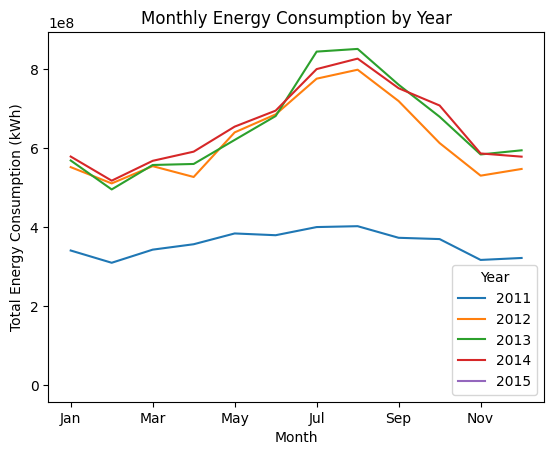

In [8]:

monthly.plot()
plt.xlabel("Month")
plt.ylabel("Total Energy Consumption (kWh)")
plt.title("Monthly Energy Consumption by Year")
plt.show()

### Create Database (SQLite)

In [9]:
df_long = df.reset_index(names="Timestamp").melt(
    id_vars="Timestamp",
    var_name="HouseID",
    value_name="Consumption_kWh"
)
print(df_long.head(), '\n')

print('Check NA \n', df_long.isna().sum())

C:\Users\Mew\AppData\Local\Temp\ipykernel_24052\1641350471.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_long = df.reset_index(names="Timestamp").melt(


            Timestamp HouseID  Consumption_kWh
0 2011-01-01 00:15:00  MT_001              0.0
1 2011-01-01 00:30:00  MT_001              0.0
2 2011-01-01 00:45:00  MT_001              0.0
3 2011-01-01 01:00:00  MT_001              0.0
4 2011-01-01 01:15:00  MT_001              0.0 

Check NA 
 Timestamp          0
HouseID            0
Consumption_kWh    0
dtype: int64


In [ ]:
from sqlalchemy import create_engine

DB_PATH = os.path.join(BASE_DIR, "..", "data", "energy.db")

engine = create_engine(f"sqlite:///{DB_PATH}")
df_long.to_sql("energy_data", engine, index=False, if_exists="replace", chunksize=10000)


In [ ]:
query = " SELECT * FROM energy_data LIMIT 5"

pd.read_sql(query, engine)


In [ ]:
query = """
SELECT
    strftime('%Y', Timestamp) AS year,
    strftime('%m', Timestamp) AS month,
    SUM(Consumption_kwh) AS total_kwh
FROM energy_data
GROUP BY year, month
ORDER BY year, month
"""

pd.read_sql(query, engine).head()